## Conditional Workflow

### Quadratic Equation workflow

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation :str
    discriminant :float
    result : str

In [13]:
def show_eqn(state: QuadState) -> QuadState:
    equation = f'{state['a']}x2 +{state['b']}x + {state['c']}'

    return {'equation' : equation}

def calculate_discriminant(state:QuadState) -> QuadState:
    discriminant = state['b']**2 - (4*state['a']*state['c'])

    return {'discriminant': discriminant}

def real_roots(state: QuadState) ->  QuadState:
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

    result = f'The roots of the equation are: {root1} and {root2}'

    return {'result': result}

def same_roots(state: QuadState) -> QuadState:
    root = (-state['b']) / (2* state['a'])

    result = f'The only repeating root of this equation is: {root}'

    return {'result': result}

def no_real_roots(state: QuadState) -> QuadState:

    result = f'No real roots'

    return {'result': result}


def check_condition(state: QuadState) -> Literal['real_roots', 'same_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return 'real_roots'
    elif state['discriminant'] == 0:
        return 'same_roots'
    else :
        return 'no_real_roots'

In [17]:
graph = StateGraph(QuadState)

graph.add_node('Show_Equation', show_eqn)
graph.add_node('Calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('same_roots', same_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'Show_Equation')
graph.add_edge('Show_Equation', 'Calculate_discriminant')

graph.add_conditional_edges('Calculate_discriminant', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('same_roots', END)
graph.add_edge('no_real_roots', END)



workflow = graph.compile()

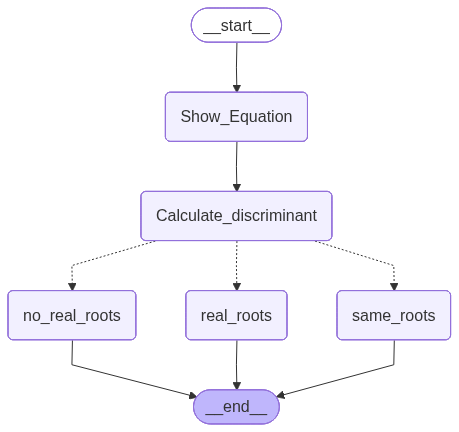

In [18]:
workflow

In [19]:
intial_state ={
    'a': 4,
    'b' : -5,
    'c' : -4
}

workflow.invoke(intial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'equation': '4x2 +-5x + -4',
 'discriminant': 89,
 'result': 'The roots of the equation are: 1.8042476415070754 and -0.5542476415070754'}